Vehicle Sales and Market Trends — Exploratory Data Analysis

The Vehicle Sales and Market Trends Dataset provides a comprehensive collection of information pertaining to the sales transactions of various vehicles. This dataset encompasses details such as the year, make, model, trim, body type, transmission type, VIN (Vehicle Identification Number), state of registration, condition rating, odometer reading, exterior and interior colors, seller information, Manheim Market Report (MMR) values, selling prices, and sale dates.

Objectives

The objective is to perform comprehensive data analysis, including data cleaning, transformation, exploratory data analysis (EDA), and visualization. The goal is to derive actionable insights and present findings effectively.

Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data Collection and Exploration

We load the dataset from a CSV file and perform an initial inspection to understand its structure, size, data types, and overall quality before making any changes.

Load the Dataset

In [4]:
data = pd.read_csv('car prices.csv')
data.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


Dataset Info

data.info() gives us a quick overview of the dataset.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


Statistical Summary

describe(include='all') gives us summary statistics for every column.

In [6]:
data.describe(include='all')

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
count,558837.000000,548536,548438,548186,545642,493485,558833,558837,547017.000000,558743.000000,558088,558088,558837,558799.000000,558825.000000,558825
unique,NaN,96,973,1963,87,4,550297,64,NaN,NaN,46,17,14263,NaN,NaN,3766
top,NaN,Ford,Altima,Base,Sedan,automatic,automatic,fl,NaN,NaN,black,black,nissan-infiniti lt,NaN,NaN,Tue Feb 10 2015 01:30:00 GMT-0800 (PST)
freq,NaN,93554,19349,55817,199437,475915,22,82945,NaN,NaN,110970,244329,19693,NaN,NaN,5334
mean,2010.038927,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.672365,68320.017767,NaN,NaN,NaN,13769.377495,13611.358810,NaN
std,3.966864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.402832,53398.542821,NaN,NaN,NaN,9679.967174,9749.501628,NaN
min,1982.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,25.000000,1.000000,NaN
25%,2007.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000,28371.000000,NaN,NaN,NaN,7100.000000,6900.000000,NaN
50%,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,52254.000000,NaN,NaN,NaN,12250.000000,12100.000000,NaN
75%,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.000000,99109.000000,NaN,NaN,NaN,18300.000000,18200.000000,NaN


Random Sample

Viewing a random sample of rows gives us a more realistic look at the actual data values.

In [7]:
data.sample(10)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
248356,1997,Ford,Escort,LX,Sedan,automatic,1falp13p3vw162061,wa,24.0,176887.0,purple,gray,lexus of bellevue,650.0,500.0,Wed Feb 04 2015 05:20:00 GMT-0800 (PST)
433676,2012,Audi,S5,3.0T Premium Plus quattro,Convertible,NaN,waucgafh1cn006972,pa,21.0,60446.0,—,red,vw credit,28000.0,27500.0,Fri May 22 2015 02:00:00 GMT-0700 (PDT)
396540,2008,Chevrolet,Impala,LT,Sedan,automatic,2g1wt58k489230302,va,2.0,135238.0,black,black,dt credit corporation,4525.0,2100.0,Thu Mar 05 2015 03:50:00 GMT-0800 (PST)
42839,2012,Nissan,Leaf,SV,Hatchback,automatic,jn1az0cp9ct026377,mo,44.0,28644.0,white,gray,nissan-infiniti lt,10950.0,11200.0,Mon Dec 22 2014 11:00:00 GMT-0800 (PST)
150034,2014,Ford,Escape,SE,SUV,automatic,1fmcu9gx1euc10207,ga,3.0,19653.0,silver,gray,ge fleet services for itself/servicer,19200.0,16300.0,Tue Feb 03 2015 05:10:00 GMT-0800 (PST)
478726,2015,Ram,2500,SLT,crew cab,automatic,3c6ur5jl7fg536310,ca,4.0,21292.0,silver,gray,enterprise fm exchange/lease,38000.0,38000.0,Wed Jun 03 2015 05:30:00 GMT-0700 (PDT)
126142,2011,Nissan,Rogue,SV,SUV,NaN,jn8as5mv5bw288152,pa,35.0,34741.0,white,black,nissan-infiniti lt,15500.0,14000.0,Fri Jan 16 2015 01:00:00 GMT-0800 (PST)
437452,2010,Ford,Explorer Sport Trac,XLT,Crew Cab,automatic,1fmeu3be9auf03956,ga,44.0,86135.0,silver,black,world toyota,14200.0,16000.0,Thu May 21 2015 03:00:00 GMT-0700 (PDT)
44456,2010,Jeep,Wrangler,Sport,SUV,NaN,1j4aa2d13al107778,ga,43.0,21002.0,silver,gray,anthony auto sales,18150.0,17600.0,Tue Dec 23 2014 13:00:00 GMT-0800 (PST)
540331,2008,Ford,F-150,XLT,supercrew,automatic,1ftrw14w18fc29872,mi,29.0,129082.0,white,gray,multi auto trading inc,11150.0,10300.0,Thu Jun 18 2015 02:30:00 GMT-0700 (PDT)


Missing Values

We check for null (missing) values in each column. Missing data can cause errors during analysis.

In [8]:
data.isna().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

Unique Value Counts

nunique() tells us how many distinct values exist in each column.

In [9]:
data.nunique()

year                34
make                96
model              973
trim              1963
body                87
transmission         4
vin             550297
state               64
condition           41
odometer        172278
color               46
interior            17
seller           14263
mmr               1101
sellingprice      1887
saledate          3766
dtype: int64

Data Cleaning and Transformation

Before analysis, we need to clean the dataset by removing columns that add no analytical value and handling missing data. Clean data ensures our visualizations and statistics are accurate and meaningful.

Drop the VIN Column

The VIN (Vehicle Identification Number) is a unique identifier for each car. Since every value is unique, it carries no useful information for trend analysis.

In [10]:
data.drop(columns=['vin'], inplace=True)

Remove Rows with Missing Values

We drop all rows that contain any null values. After this step, we verify the dataset no longer has missing data using.

In [11]:
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 472325 entries, 0 to 558836
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          472325 non-null  int64  
 1   make          472325 non-null  object 
 2   model         472325 non-null  object 
 3   trim          472325 non-null  object 
 4   body          472325 non-null  object 
 5   transmission  472325 non-null  object 
 6   state         472325 non-null  object 
 7   condition     472325 non-null  float64
 8   odometer      472325 non-null  float64
 9   color         472325 non-null  object 
 10  interior      472325 non-null  object 
 11  seller        472325 non-null  object 
 12  mmr           472325 non-null  float64
 13  sellingprice  472325 non-null  float64
 14  saledate      472325 non-null  object 
dtypes: float64(4), int64(1), object(10)
memory usage: 57.7+ MB


Verify the Cleaned Data

A quick random sample confirms the data looks correct after cleaning.

In [12]:
data.sample(10)

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
226756,2010,Dodge,Charger,Rallye,Sedan,automatic,wi,32.0,40683.0,black,black,capital one auto finance,11950.0,13500.0,Wed Feb 04 2015 02:30:00 GMT-0800 (PST)
527425,2008,Cadillac,Escalade ESV,Base,suv,automatic,mi,22.0,86507.0,white,tan,kearns motor car co inc,23000.0,20800.0,Thu Jun 11 2015 02:30:00 GMT-0700 (PDT)
87177,2013,Nissan,Rogue,S,SUV,automatic,tx,39.0,64584.0,black,black,the hertz corporation,12100.0,13000.0,Wed Jan 21 2015 02:05:00 GMT-0800 (PST)
409909,2013,Toyota,RAV4,LE,SUV,automatic,il,37.0,53381.0,gray,gray,the hertz corporation,16150.0,16001.0,Tue May 26 2015 03:00:00 GMT-0700 (PDT)
189293,2013,Infiniti,FX,FX37,SUV,automatic,mo,4.0,41842.0,gray,black,the hertz corporation,27400.0,26500.0,Tue Mar 03 2015 03:00:00 GMT-0800 (PST)
138565,2012,Ford,E-Series Wagon,E-350 Super Duty XL,Van,automatic,ga,39.0,50218.0,white,gray,american van rental,16650.0,17100.0,Thu Jan 29 2015 02:00:00 GMT-0800 (PST)
341602,2013,Dodge,Avenger,SXT,Sedan,automatic,sc,5.0,2121.0,white,beige,carolina chrysler dodge jeep ram,12250.0,13100.0,Thu Feb 19 2015 02:00:00 GMT-0800 (PST)
275022,2008,Chrysler,Sebring,LX,Sedan,automatic,va,1.0,137008.0,gray,gray,dt credit corporation,2650.0,1000.0,Thu Feb 12 2015 03:50:00 GMT-0800 (PST)
444039,2014,Nissan,Versa,1.6 SV,Sedan,manual,ca,3.0,44854.0,black,black,bmw alphera/alphera financial services,7525.0,7400.0,Tue Jun 02 2015 05:30:00 GMT-0700 (PDT)
506621,2014,Ford,Explorer,XLT,suv,automatic,tx,37.0,34632.0,brown,beige,avis budget group,24400.0,25000.0,Wed Jun 10 2015 02:30:00 GMT-0700 (PDT)


Standardize the Body Column

The body column contains inconsistent casing (e.g. 'SUV', 'Suv', 'suv'). We convert all values to uppercase to ensure consistent grouping in visualizations.

In [13]:
data['body'] = data['body'].str.upper()


Univariate Analysis

Univariate analysis examines each variable individually to understand its distribution and frequency. We start with a broad overview before diving into specific columns.

Overview Histograms (All Numerical Columns)

Plotting histograms for all numerical columns at once gives a quick visual summary of how each variable is distributed.

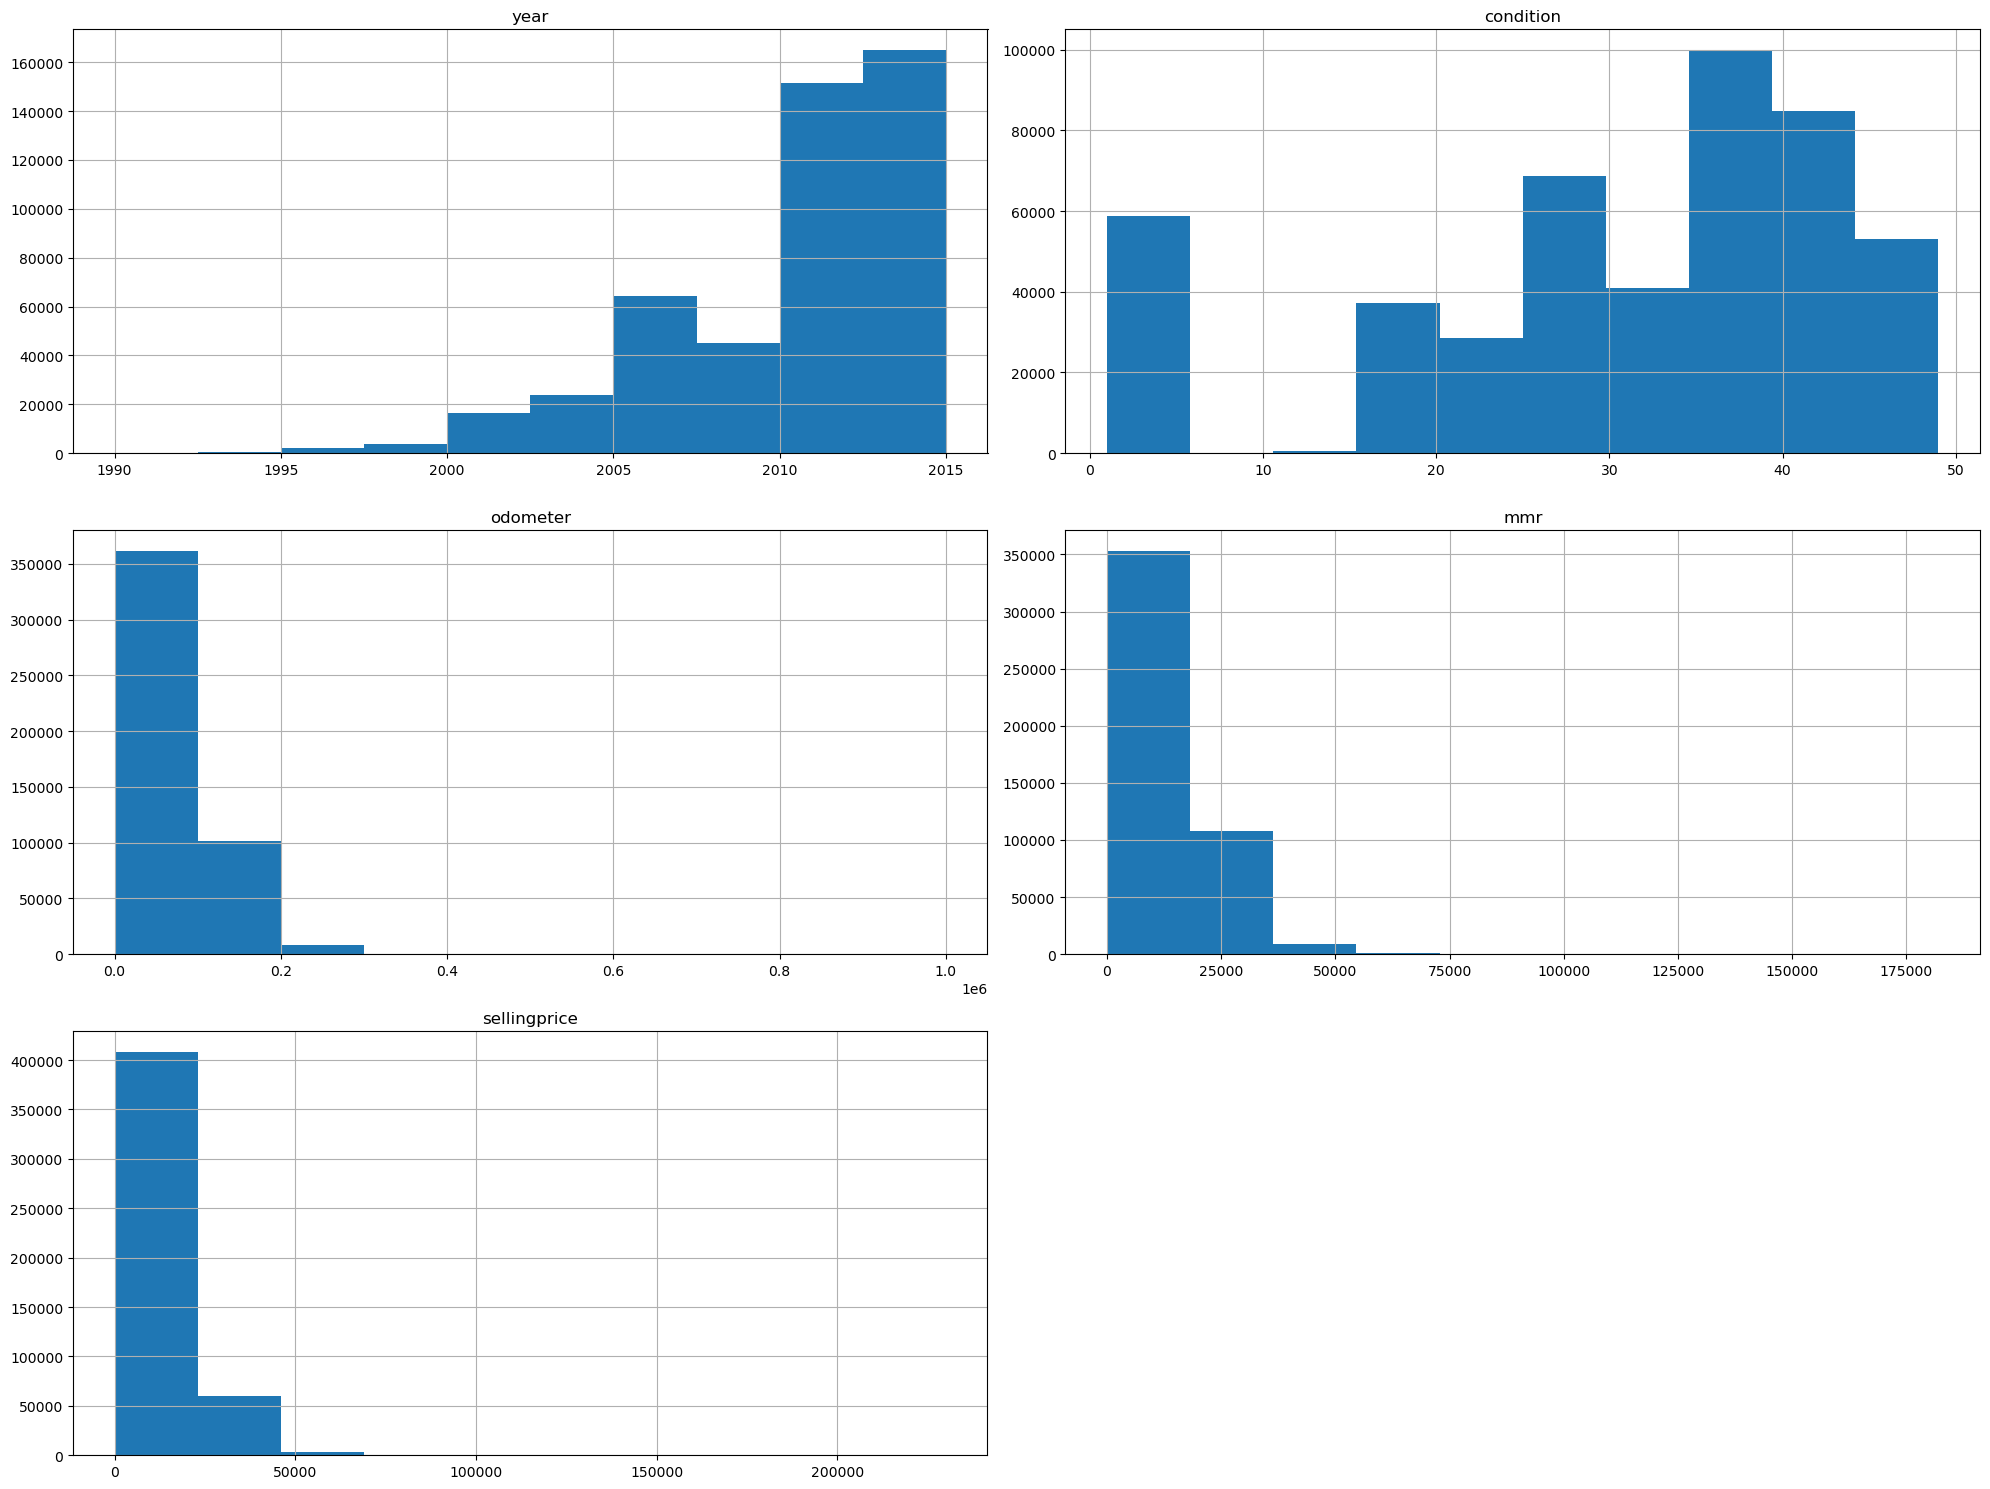

In [14]:
data.hist(figsize=(20, 15))
plt.tight_layout()
plt.show()

Distribution of Car Manufacturing Year

We look at how many cars in the dataset were manufactured each year.

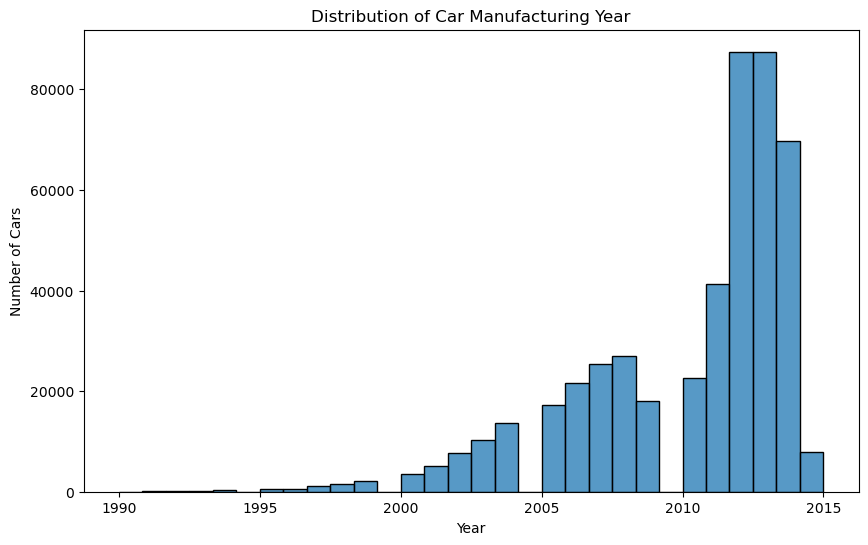

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(data['year'], bins=30)
plt.title('Distribution of Car Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Number of Cars')
plt.show()

The number of car sales has massively grown since the 2010s, indicating that newer vehicles dominate the used car market.

Transmission Type Distribution

We explore how cars are distributed across transmission types automatic and manual.

In [16]:
trans = data.transmission.value_counts()
print(trans)

transmission
automatic    455963
manual        16362
Name: count, dtype: int64


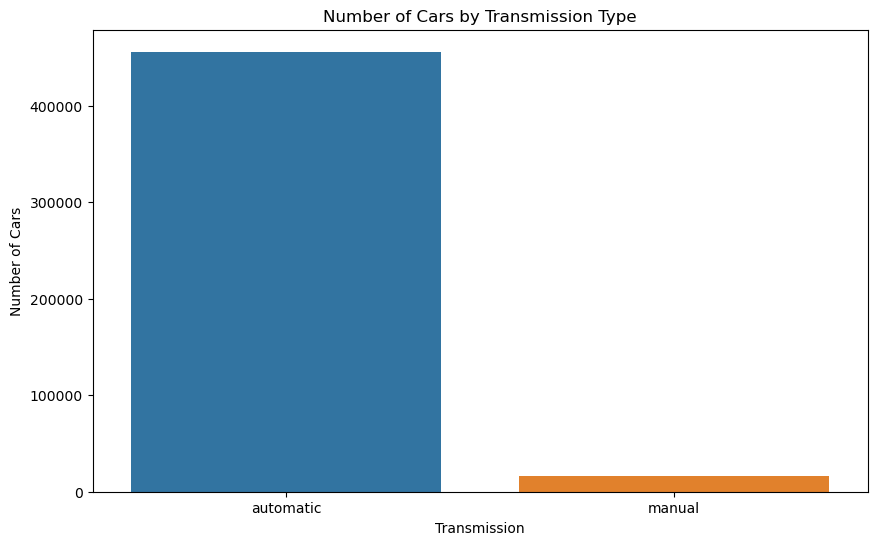

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='transmission', order=data['transmission'].value_counts().index, hue='transmission')
plt.title('Number of Cars by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Number of Cars')
plt.show()

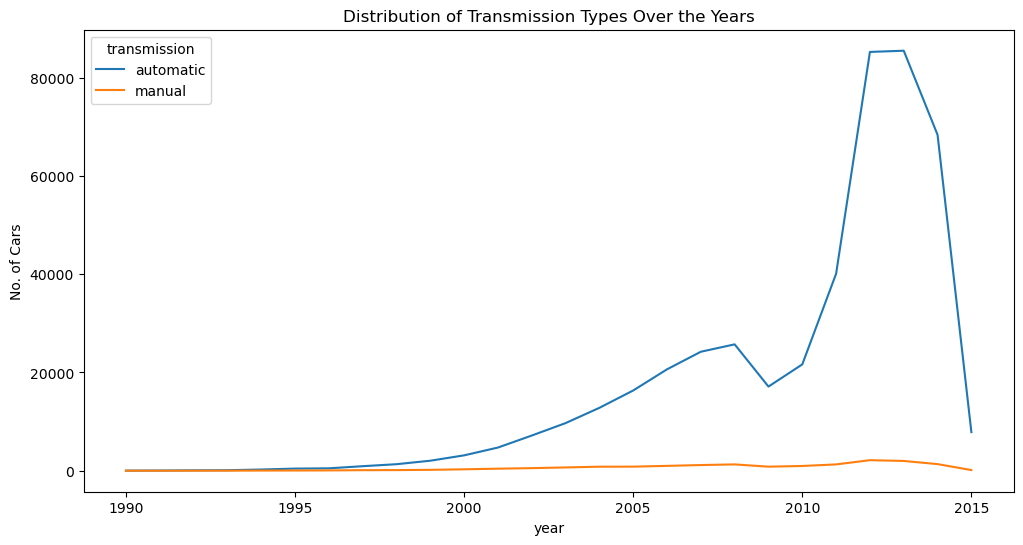

In [18]:
pd.crosstab(data['year'], data['transmission']).plot(kind='line', figsize=(12, 6))
plt.title('Distribution of Transmission Types Over the Years')
plt.ylabel('No. of Cars')
plt.show()

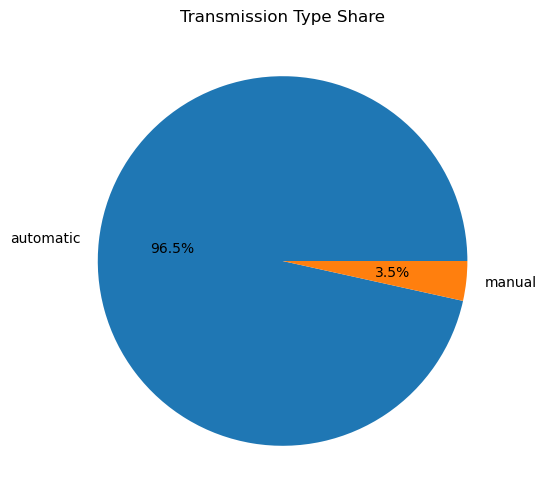

In [19]:
plt.figure(figsize=(6, 6))
data['transmission'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Transmission Type Share')
plt.ylabel('')
plt.show()

Automatic transmission dominates the market and has grown significantly over the years compared to manual.

Transmission Type by State

We cross-tabulate transmission types against states to confirm whether the automatic dominance is a national trend or specific to certain regions.

In [20]:
state = data.state.value_counts()
print(state)

state
fl    75243
ca    66213
tx    41657
ga    30939
pa    24117
nj    23003
il    21494
oh    20294
tn    19183
nc    18731
mo    15286
mi    14185
nv    11682
md     9788
va     9448
wi     9196
mn     8627
az     7612
wa     7012
co     6270
ma     6167
ny     4749
in     3879
sc     3754
ne     3685
pr     2427
la     1744
ms     1730
ut     1716
hi     1205
or     1047
nm      163
ok       54
al       25
Name: count, dtype: int64


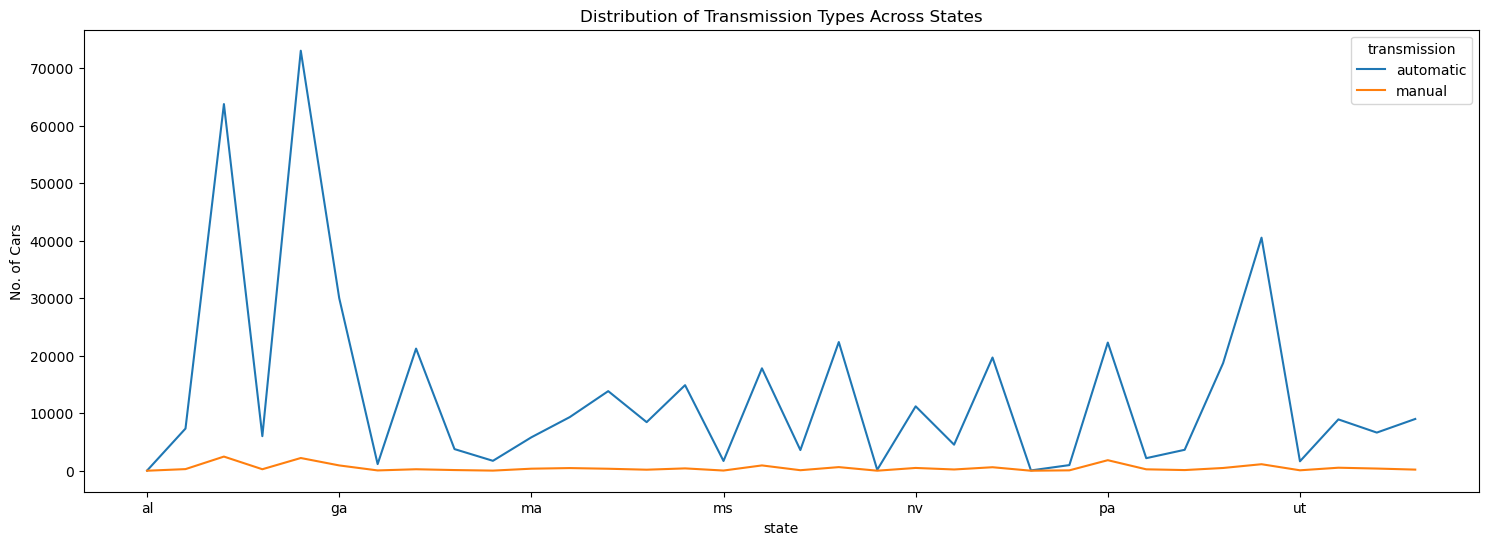

In [21]:
pd.crosstab(data['state'], data['transmission']).plot(kind='line', figsize=(18, 6))
plt.title('Distribution of Transmission Types Across States')
plt.ylabel('No. of Cars')
plt.show()

The higher number of automatic transmission sales is consistent across all states.

Car Manufacturers (Make)

We look at how many cars each manufacturer has in the dataset to understand market share.

In [22]:
make = data.make.value_counts()
print(make)

make
Ford             81013
Chevrolet        54150
Nissan           44043
Toyota           35313
Dodge            27181
Honda            24781
Hyundai          18659
BMW              17509
Kia              15828
Chrysler         15133
Infiniti         14011
Mercedes-Benz    14008
Jeep             12735
Volkswagen       10780
Lexus            10409
GMC               9217
Mazda             6930
Cadillac          6315
Lincoln           4926
Audi              4802
Acura             4503
Buick             4470
Subaru            4369
Ram               4044
Pontiac           4018
Mitsubishi        3661
Volvo             3082
MINI              2946
Saturn            2570
Mercury           1571
Scion             1545
Land Rover        1322
Jaguar            1257
Porsche           1157
Suzuki             977
HUMMER             768
FIAT               725
Saab               416
smart              343
Oldsmobile         318
Isuzu              179
Maserati           109
Bentley            105
Aston 

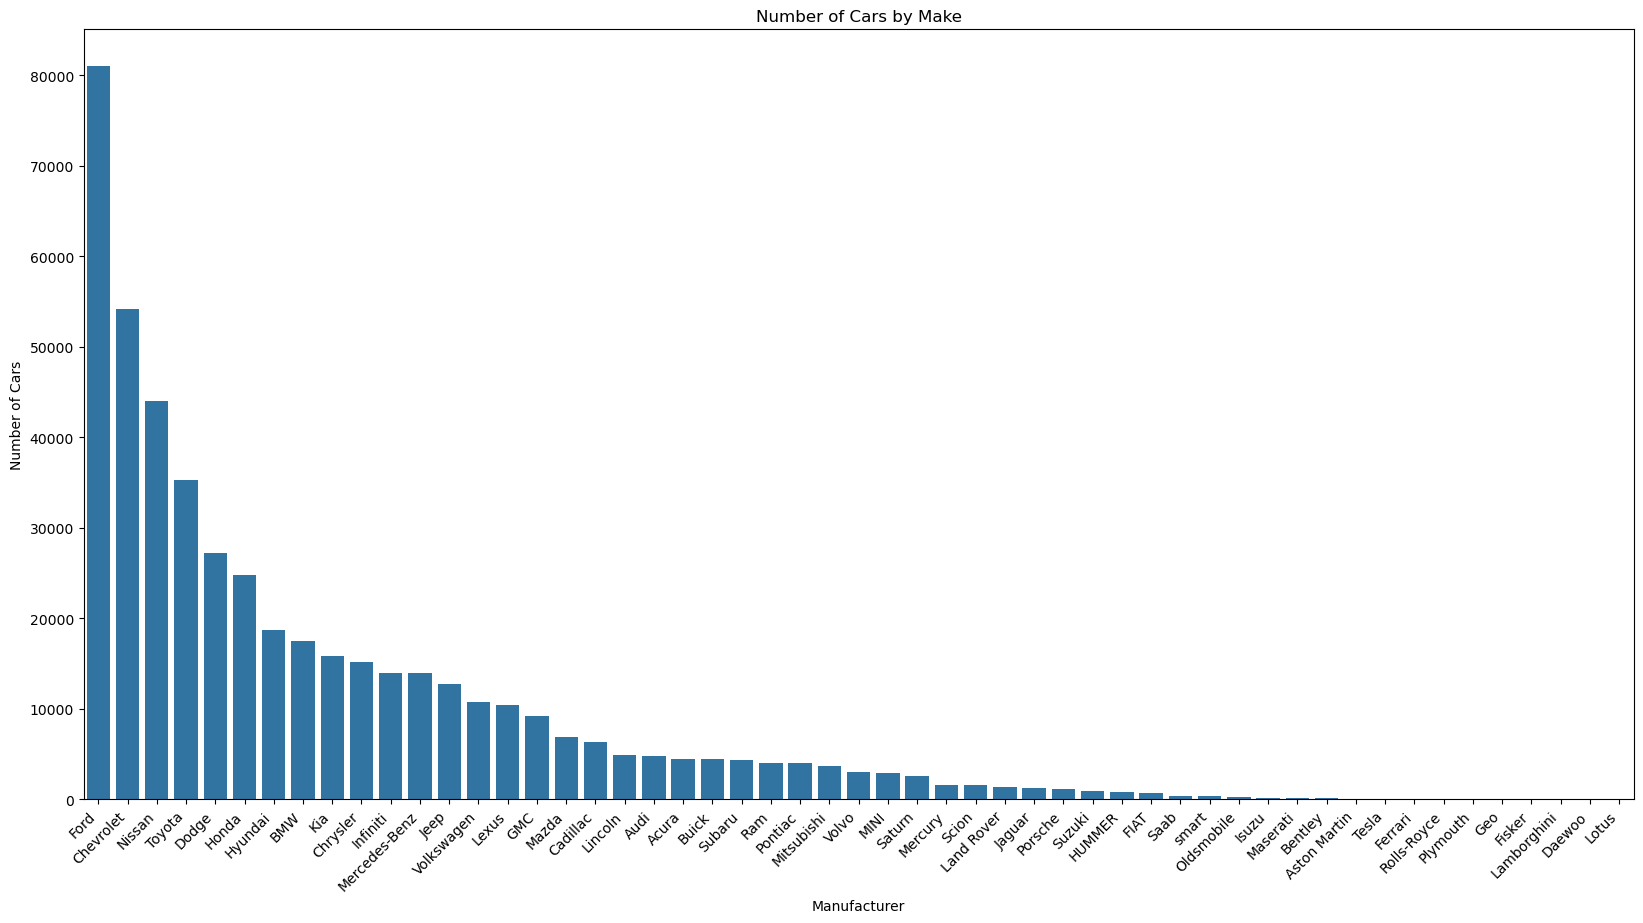

In [23]:
plt.figure(figsize=(20, 10))
sns.countplot(data=data, x='make', order=data['make'].value_counts().index)
plt.title('Number of Cars by Make')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45, ha='right')
plt.show()

 Domestic manufacturers Ford and Chevrolet hold the largest market share, followed by Japanese (Toyota, Nissan), Korean (Hyundai, Kia), and then the European manufacturers.

Vehicle Body Types

We examine which body types (SUV, Sedan, Coupe, etc.) are most prevalent in the dataset.

In [24]:
body = data.body.value_counts()
print(body)

body
SEDAN                      211298
SUV                        120968
HATCHBACK                   23821
MINIVAN                     21938
COUPE                       15960
CREW CAB                    14249
WAGON                       14223
CONVERTIBLE                  9318
SUPERCREW                    7562
G SEDAN                      6939
SUPERCAB                     4178
REGULAR CAB                  4064
EXTENDED CAB                 3956
QUAD CAB                     3516
VAN                          3513
G COUPE                      1504
DOUBLE CAB                   1468
E-SERIES VAN                 1108
CREWMAX CAB                   488
KING CAB                      446
G CONVERTIBLE                 306
ACCESS CAB                    266
GENESIS COUPE                 255
KOUP                          162
CLUB CAB                      150
CTS COUPE                     120
MEGA CAB                       97
ELANTRA COUPE                  87
PROMASTER CARGO VAN            56
BEETLE CO

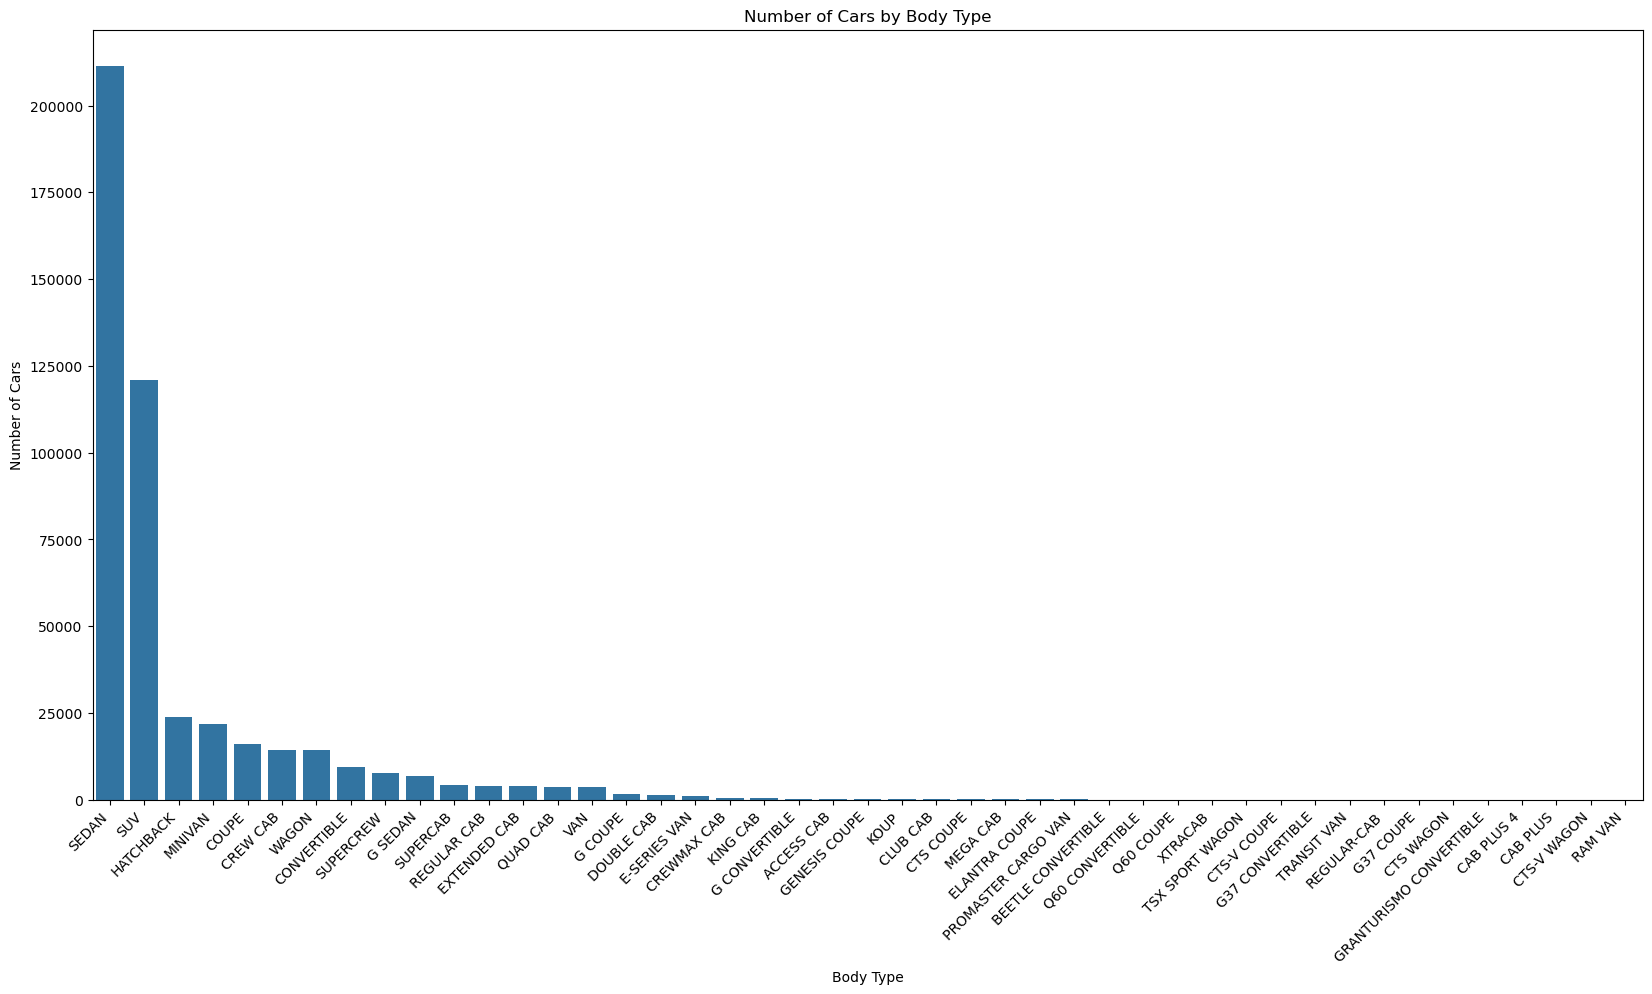

In [25]:
plt.figure(figsize=(20, 10))
sns.countplot(data=data, x='body', order=data['body'].value_counts().index)
plt.title('Number of Cars by Body Type')
plt.xlabel('Body Type')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45, ha='right')
plt.show()

We see Sedans and SUVs dominate the market dwarfing even the next closest body type, Hatchback, Minivan, and Coupe.

Outlier Detection and Removal

An outlier is a data point that is significantly different from the rest of the dataset.

We use the Interquartile Range (IQR) method:
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 − Q1
- Any value below **Q1 − 1.5×IQR** or above **Q3 + 1.5×IQR** is flagged as an outlier

Visualize Selling Price Before Cleaning

A box plot clearly shows outliers as individual points beyond the whiskers.

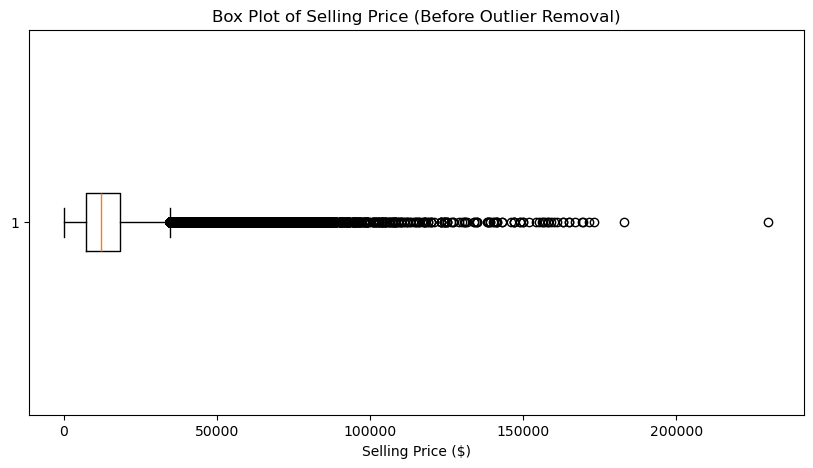

In [26]:
plt.figure(figsize=(10, 5))
plt.boxplot(data['sellingprice'], vert=False)
plt.title('Box Plot of Selling Price (Before Outlier Removal)')
plt.xlabel('Selling Price ($)')
plt.show()

The outliers lie beyond the upper bound of the data.

Detect Outliers Using IQR

In [27]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers, lower_bound, upper_bound = detect_outliers_iqr(data, 'sellingprice')

print(f'Lower Bound : {lower_bound}')
print(f'Upper Bound : {upper_bound}')
print(f'Outliers Detected : {len(outliers)}')
print(f'Original Data Shape: {data.shape}')

Lower Bound : -9300.0
Upper Bound : 34700.0
Outliers Detected : 14118
Original Data Shape: (472325, 15)


Remove Outliers

In [28]:
cleaned_data = data[(data['sellingprice'] >= lower_bound) & (data['sellingprice'] <= upper_bound)]

print('Original data shape :', data.shape)
print('Cleaned data shape  :', cleaned_data.shape)

Original data shape : (472325, 15)
Cleaned data shape  : (458207, 15)


Inspecting Data after Cleaning

In [40]:
cleaned_data

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,price_diff
0,2015,Kia,Sorento,LX,SUV,automatic,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),1000.0
1,2015,Kia,Sorento,LX,SUV,automatic,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),700.0
2,2014,BMW,3 Series,328i SULEV,SEDAN,automatic,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST),-1900.0
3,2015,Volvo,S60,T5,SEDAN,automatic,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST),250.0
5,2015,Nissan,Altima,2.5 S,SEDAN,automatic,ca,1.0,5554.0,gray,black,enterprise vehicle exchange / tra / rental / t...,15350.0,10900.0,Tue Dec 30 2014 12:00:00 GMT-0800 (PST),-4450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558831,2011,BMW,5 Series,528i,SEDAN,automatic,fl,39.0,66403.0,white,brown,lauderdale imports ltd bmw pembrok pines,20300.0,22800.0,Tue Jul 07 2015 06:15:00 GMT-0700 (PDT),2500.0
558833,2012,Ram,2500,Power Wagon,CREW CAB,automatic,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT),600.0
558834,2012,BMW,X5,xDrive35d,SUV,automatic,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT),4200.0
558835,2015,Nissan,Altima,2.5 S,SEDAN,automatic,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT),-4000.0


Visualize Selling Price After Cleaning

Comparing the box plot before and after removal of Outliers.

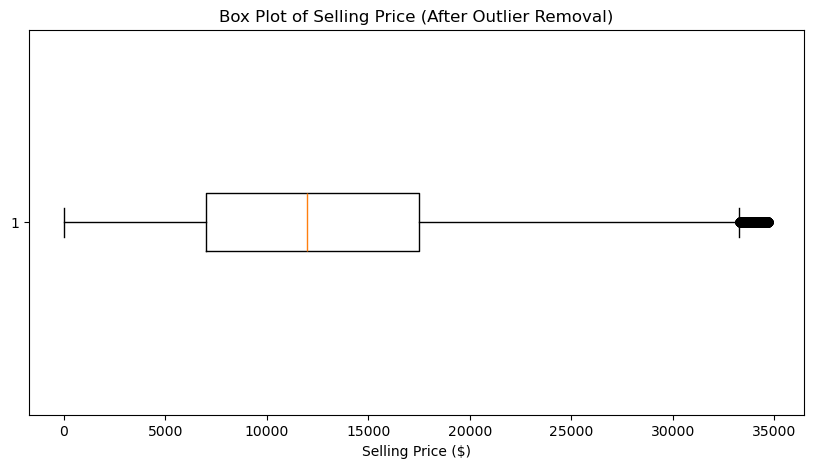

In [29]:
plt.figure(figsize=(10, 5))
plt.boxplot(cleaned_data['sellingprice'], vert=False)
plt.title('Box Plot of Selling Price (After Outlier Removal)')
plt.xlabel('Selling Price ($)')
plt.show()

Compare Summary Statistics Before and After

Comparing descriptive statistics before and after removal shows how much the outliers were affecting the mean and standard deviation.

In [30]:
print('Original Summary Statistics:')
print(data['sellingprice'].describe())
print('\nCleaned Summary Statistics:')
print(cleaned_data['sellingprice'].describe())

Original Summary Statistics:
count    472325.000000
mean      13690.512058
std        9613.033738
min           1.000000
25%        7200.000000
50%       12200.000000
75%       18200.000000
max      230000.000000
Name: sellingprice, dtype: float64

Cleaned Summary Statistics:
count    458207.000000
mean      12723.153350
std        7630.786556
min           1.000000
25%        7000.000000
50%       12000.000000
75%       17500.000000
max       34700.000000
Name: sellingprice, dtype: float64


Selling Price Distribution

Now that outliers are removed, we examine the distribution of selling prices. A histogram with KDE (Kernel Density Estimate) shows both the frequency and the shape of the distribution.

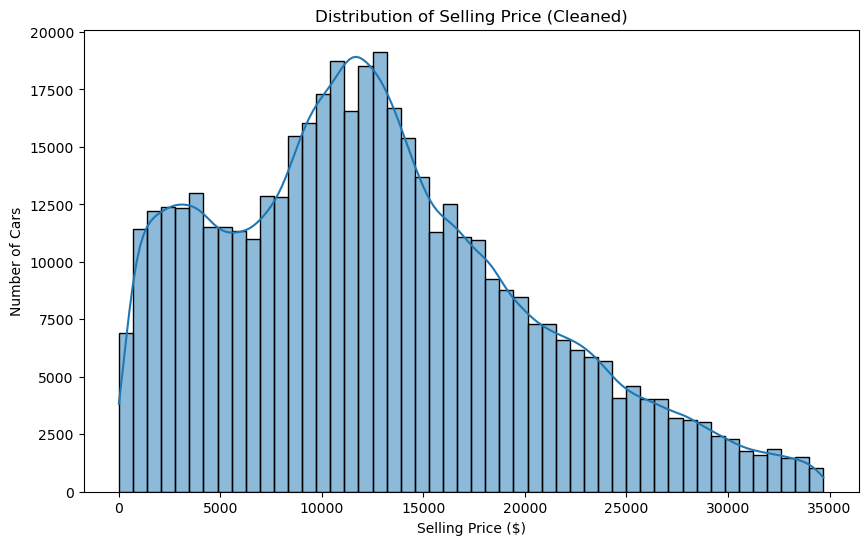

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(cleaned_data['sellingprice'], bins=50, kde=True)
plt.title('Distribution of Selling Price (Cleaned)')
plt.xlabel('Selling Price ($)')
plt.ylabel('Number of Cars')
plt.show()

Correlation Analysis

A correlation matrix displays the correlation coefficients between every pair of numerical variables. The coefficient ranges from -1 to +1:

- +1 → Perfect positive correlation (both variables increase together)
-  0 → No linear relationship
- -1 → Perfect negative correlation (one increases as the other decreases)

Correlation Matrix

In [32]:
correlation_matrix = cleaned_data[['year', 'condition', 'odometer', 'mmr', 'sellingprice']].corr()
print('Correlation Matrix:')
print(correlation_matrix)

Correlation Matrix:
                  year  condition  odometer       mmr  sellingprice
year          1.000000   0.336857 -0.769651  0.662404      0.649565
condition     0.336857   1.000000 -0.314822  0.307649      0.360640
odometer     -0.769651  -0.314822  1.000000 -0.643089     -0.635753
mmr           0.662404   0.307649 -0.643089  1.000000      0.977139
sellingprice  0.649565   0.360640 -0.635753  0.977139      1.000000


Correlation Heatmap

A heatmap makes it easy to spot strong and weak correlations at a glance using color intensity.

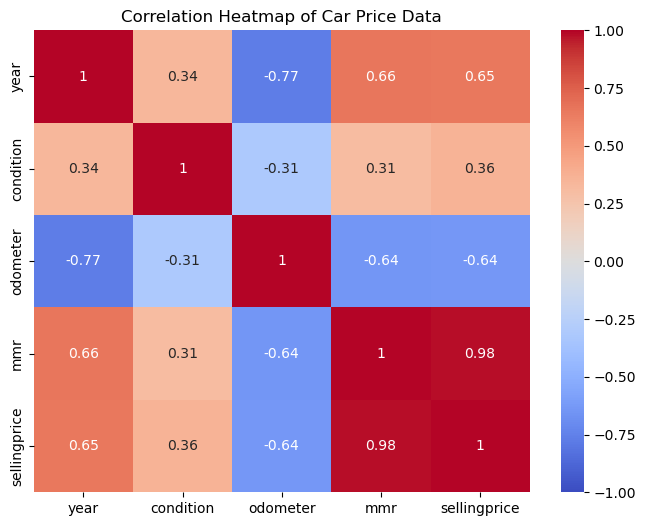

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Car Price Data')
plt.show()

# annot=True : Shows the actual correlation value inside each cell
# cmap='coolwarm' : Blue = negative correlation, Red = positive correlation

mmr and sellingprice have near-perfect positive correlation meaning market value closely predicts selling price.

odometer shows negative correlation with price meaning higher mileage cars sell for less.

condition shows positive correlation with price meaning better condition fetches higher prices.

Pair Plot

A pair plot (scatter matrix) shows the relationship between every pair of numerical variables at once. The diagonal shows the distribution of each variable (KDE), while the off-diagonal cells show scatter plots. We use a sample of 3000 rows for performance.

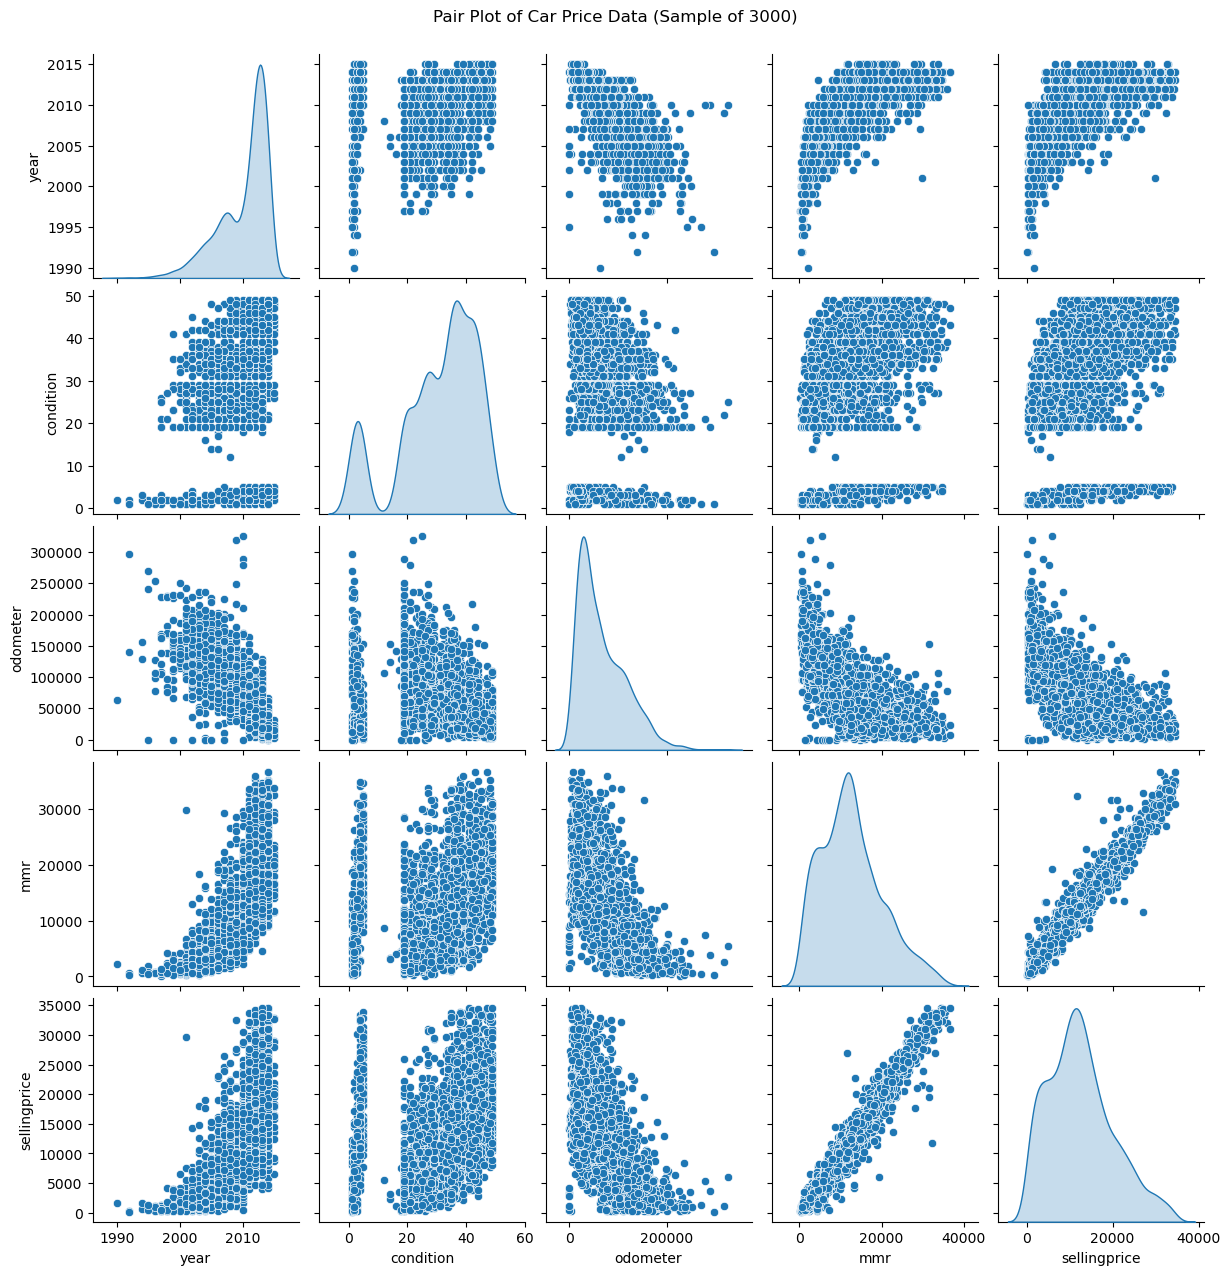

In [34]:
sample = cleaned_data[['year', 'condition', 'odometer', 'mmr', 'sellingprice']].sample(3000, random_state=42)

sns.pairplot(sample, diag_kind='kde')
plt.suptitle('Pair Plot of Car Price Data (Sample of 3000)', y=1.02)
plt.show()


Creating new Feature — Price Difference (Selling Price vs MMR)

Here, we compute price_diff = sellingprice − mmr:

The MMR (Manheim Market Report) value is the estimated market value of the car

A positive price_diff means the car sold above market value

A negative price_diff means the car sold below market value

In [35]:
cleaned_data = cleaned_data.copy()  # Avoid SettingWithCopyWarning
cleaned_data['price_diff'] = cleaned_data['sellingprice'] - cleaned_data['mmr']

print(cleaned_data[['mmr', 'sellingprice', 'price_diff']].head(10))

        mmr  sellingprice  price_diff
0   20500.0       21500.0      1000.0
1   20800.0       21500.0       700.0
2   31900.0       30000.0     -1900.0
3   27500.0       27750.0       250.0
5   15350.0       10900.0     -4450.0
7   11900.0        9800.0     -2100.0
8   32100.0       32250.0       150.0
9   26300.0       17500.0     -8800.0
11  15150.0       17700.0      2550.0
12  15350.0       12000.0     -3350.0


In [36]:
print('Summary of Price Difference (Selling Price - MMR):')
print(cleaned_data['price_diff'].describe())

Summary of Price Difference (Selling Price - MMR):
count    458207.000000
mean       -162.753566
std        1626.360196
min      -87750.000000
25%        -800.000000
50%         -50.000000
75%         625.000000
max       24050.000000
Name: price_diff, dtype: float64


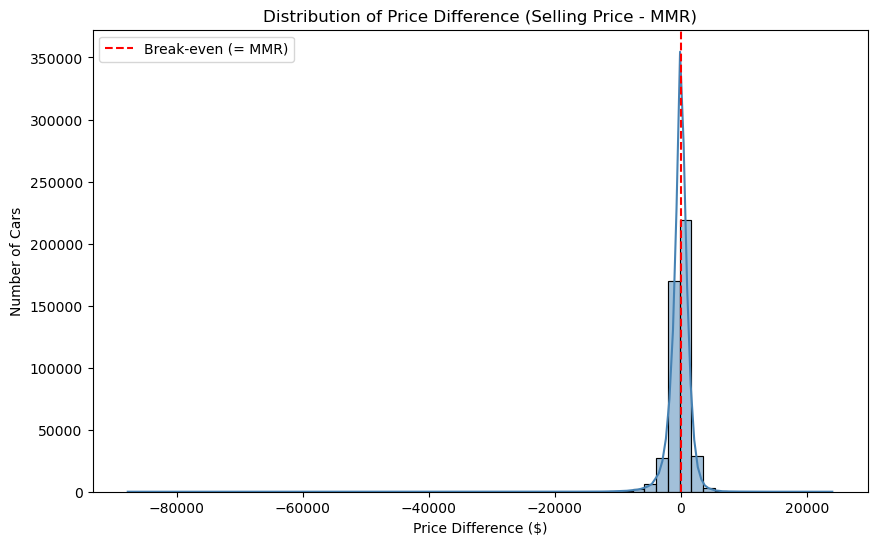

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(cleaned_data['price_diff'], bins=60, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--', label='Break-even (= MMR)')
plt.title('Distribution of Price Difference (Selling Price - MMR)')
plt.xlabel('Price Difference ($)')
plt.ylabel('Number of Cars')
plt.legend()
plt.show()

The distribution is centered slightly below zero, meaning most cars sell at or just below their MMR market value. Large positive outliers indicate premium sales (luxury or rare vehicles).

Save Cleaned Data

Cleaned and enriched dataset to a new CSV file.

In [38]:
# Check for any nulls before saving
cleaned_data['price_diff'] = cleaned_data['price_diff'].fillna(0.0)
print('Null values remaining:')
print(cleaned_data.isna().sum())

Null values remaining:
year            0
make            0
model           0
trim            0
body            0
transmission    0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
price_diff      0
dtype: int64


In [39]:
cleaned_data.to_csv('cleaned_car_prices.csv', index=False)
print(f'Cleaned data saved to cleaned_car_prices.csv')
print(f'Final shape: {cleaned_data.shape}')

Cleaned data saved to cleaned_car_prices.csv
Final shape: (458207, 16)
